### Restaurant Demand Forecasting

#### Synthetic Dataset Generation

Accurate demand forecasting is critical for restaurant operations.  
Restaurants must anticipate customer demand to optimize staffing,
inventory management, and promotional strategies.

In this notebook we generate a **synthetic dataset** representing daily
restaurant demand.

The dataset simulates several real-world drivers of demand:

• weekly seasonality (higher demand on weekends)  
• yearly seasonality  
• weather conditions  
• promotions and holidays  
• local events and tourism seasons  
• economic slowdowns  
• long-term growth trends  

This dataset will later be used for:

• exploratory data analysis  
• feature engineering  
• machine learning forecasting models

In [1]:
"""
Import required libraries for dataset generation and visualization.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Ensure reproducibility
np.random.seed(42)

In [2]:
"""
Create a daily time series covering multiple years.

A long time horizon allows forecasting models to learn
seasonal patterns and long-term trends.
"""

dates = pd.date_range(
    start="2016-01-01",
    end="2023-12-31",
    freq="D"
)

df = pd.DataFrame({"date": dates})

df.head()

,date
0,2016-01-01
1,2016-01-02
2,2016-01-03
3,2016-01-04
4,2016-01-05


In [3]:
"""
Extract calendar-based features from the date column.
These variables are commonly used in time-series forecasting.
"""

df["day_of_week"] = df["date"].dt.day_name()
df["dow"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

# Weekend indicator
df["is_weekend"] = df["dow"].isin([5, 6]).astype(int)

df.head()

,date,day_of_week,dow,month,year,week_of_year,is_weekend
0,2016-01-01,Friday,4,1,2016,53,0
1,2016-01-02,Saturday,5,1,2016,53,1
2,2016-01-03,Sunday,6,1,2016,53,1
3,2016-01-04,Monday,0,1,2016,1,0
4,2016-01-05,Tuesday,1,1,2016,1,0


In [4]:
"""
Simulate weekly demand patterns.

Restaurants typically experience higher demand during weekends.
"""

df["weekly_factor"] = 1 + (df["is_weekend"] * 0.25)

In [5]:
"""
Simulate yearly seasonality using a sinusoidal pattern.

Demand fluctuates throughout the year due to tourism,
weather changes, and holiday seasons.
"""

df["seasonal_factor"] = (
    1 + 0.2 * np.sin(2 * np.pi * df["date"].dt.dayofyear / 365)
)

In [6]:
"""
Simulate long-term demand growth.

Restaurant demand may increase over time due to
brand reputation, population growth, or market expansion.
"""

df["trend"] = np.linspace(1, 1.25, len(df))

In [7]:
"""
Generate synthetic weather conditions.
"""

# Temperature with yearly seasonality
df["temperature"] = (
    20
    + 10 * np.sin(2 * np.pi * df["date"].dt.dayofyear / 365)
    + np.random.normal(0, 3, len(df))
)

# Rain probability
df["rain"] = np.random.binomial(1, 0.3, len(df))

In [8]:
"""
Simulate external drivers of restaurant demand.
"""

# Holidays
df["holiday"] = np.random.binomial(1, 0.03, len(df))

# Promotions
df["promotion"] = np.random.binomial(1, 0.10, len(df))

# Local events
df["local_event"] = np.random.binomial(1, 0.05, len(df))

# Tourism season (summer months)
df["tourism_season"] = df["month"].isin([6, 7, 8]).astype(int)

In [9]:
"""
Simulate festival weeks that increase restaurant demand.
"""

df["festival_week"] = 0

for _ in range(20):
    start = np.random.randint(0, len(df) - 7)
    df.loc[start:start+6, "festival_week"] = 1

In [10]:
"""
Simulate a temporary economic slowdown period.
"""

df["economic_slowdown"] = 0

slowdown_start = int(len(df) * 0.65)

df.loc[slowdown_start:slowdown_start+120, "economic_slowdown"] = 1

In [11]:
"""
Generate base restaurant demand combining key demand drivers.
"""

base = 150

df["base_orders"] = (
    base
    * df["weekly_factor"]
    * df["seasonal_factor"]
    * df["trend"]
)

In [12]:
"""
Modify demand using external factors.
"""

df["total_orders"] = df["base_orders"]

df.loc[df["promotion"] == 1, "total_orders"] *= 1.15
df.loc[df["holiday"] == 1, "total_orders"] *= 1.10
df.loc[df["local_event"] == 1, "total_orders"] *= 1.20
df.loc[df["tourism_season"] == 1, "total_orders"] *= 1.10
df.loc[df["festival_week"] == 1, "total_orders"] *= 1.15
df.loc[df["economic_slowdown"] == 1, "total_orders"] *= 0.9

In [13]:
"""
Add random noise to simulate real-world demand variability.
"""

df["total_orders"] += np.random.normal(0, 15, len(df))

df["total_orders"] = df["total_orders"].round().astype(int)

df["total_orders"] = df["total_orders"].clip(lower=0)

In [14]:
"""
Inspect dataset structure.
"""

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (2922, 20)


,date,day_of_week,dow,month,year,week_of_year,is_weekend,weekly_factor,seasonal_factor,trend,temperature,rain,holiday,promotion,local_event,tourism_season,festival_week,economic_slowdown,base_orders,total_orders
0,2016-01-01,Friday,4,1,2016,53,0,1.00,1.003443,1.000000,21.662276,0,0,0,0,0,0,0,150.516401,122
1,2016-01-02,Saturday,5,1,2016,53,1,1.25,1.006884,1.000086,19.929423,0,0,0,0,0,0,0,188.806968,173
2,2016-01-03,Sunday,6,1,2016,53,1,1.25,1.010324,1.000171,22.459262,1,0,0,1,0,0,0,189.468164,229
3,2016-01-04,Monday,0,1,2016,1,0,1.00,1.013760,1.000257,25.257114,0,0,0,0,0,0,0,152.103117,173
4,2016-01-05,Tuesday,1,1,2016,1,0,1.00,1.017193,1.000342,20.157188,1,0,0,0,0,0,0,152.631179,168


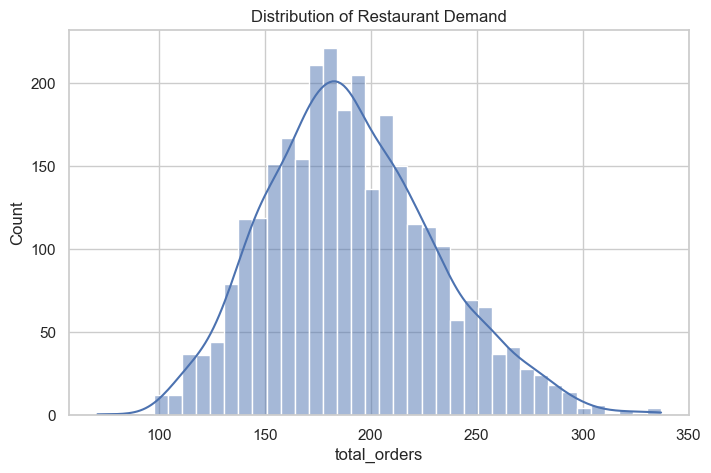

In [15]:
"""
Visualize distribution of restaurant demand.
"""

plt.figure(figsize=(8,5))

sns.histplot(
    df["total_orders"],
    bins=40,
    kde=True
)

plt.title("Distribution of Restaurant Demand")

plt.show()

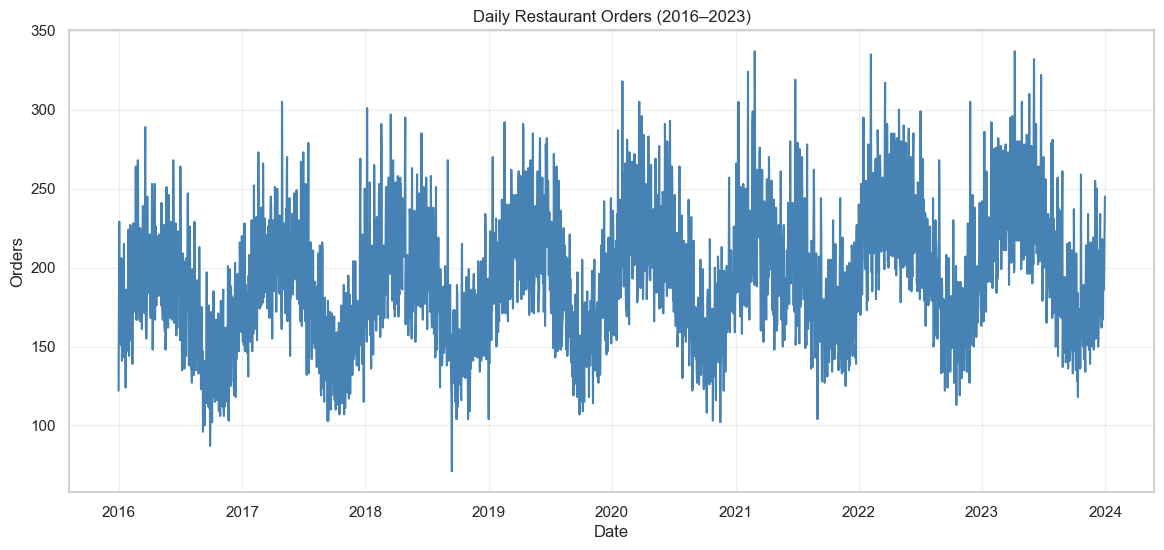

In [16]:
"""
Visualize the restaurant demand time series.
"""

plt.figure(figsize=(14,6))

plt.plot(
    df["date"],
    df["total_orders"],
    color="steelblue"
)

plt.title("Daily Restaurant Orders (2016–2023)")

plt.xlabel("Date")
plt.ylabel("Orders")

plt.grid(alpha=0.3)

plt.show()

In [17]:
df.columns

Index(['date', 'day_of_week', 'dow', 'month', 'year', 'week_of_year',
       'is_weekend', 'weekly_factor', 'seasonal_factor', 'trend',
       'temperature', 'rain', 'holiday', 'promotion', 'local_event',
       'tourism_season', 'festival_week', 'economic_slowdown', 'base_orders',
       'total_orders'],
      dtype='object')

In [18]:
"""
Save dataset for use in later notebooks.
"""

df.to_csv("../data/restaurant_orders.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


#### Final Synthetic Dataset

The generated dataset simulates daily restaurant demand between **2016 and 2023**.

The demand signal combines several realistic drivers commonly observed in
restaurant operations:

• **Weekly seasonality** – higher demand during weekends  
• **Yearly seasonality** – tourism and weather-related fluctuations  
• **Long-term trend** – gradual growth in restaurant popularity  
• **Weather conditions** – temperature and rain indicators  
• **Promotions and holidays** – temporary increases in demand  
• **Local events and festivals** – spikes caused by nearby activities  
• **Tourism seasonality** – increased activity during summer months  
• **Economic slowdown** – temporary reduction in demand  

Random noise was added to mimic real-world variability in daily restaurant orders.

The resulting dataset will be used in the following notebooks for:

• **Exploratory Data Analysis (EDA)**  
• **Feature Engineering**  
• **Machine Learning Forecasting Models**  
• **Model Explainability**

The dataset is saved for use in downstream analysis and modeling.